# 🔍 11-03 · 时间序列分解：趋势 / 季节 / 残差各归其位

> 目标：把序列拆成可解释的三块。手写**中心化移动平均去趋势 + 季节指数**，
> 完成「分解 → 残差诊断 → 评价分解质量」的经典流程，理解 STL 的原理。

> 🧩 **生活化类比**：分解 = 把"一年销售曲线"拆成三张图——长期走势（趋势）、
> 每年固定节奏（季节）、以及"说不清道不明"的部分（残差）。残差越小，模型越完整。


## 1. 加法与乘法模型

- 加法：$y_t = T_t + S_t + R_t$ —— 季节幅度不随水平变化
- 乘法：$y_t = T_t \\times S_t \\times R_t$ —— 季节幅度随水平缩放（销售额越高波动越大）
- 对数变换可把乘法转加法：$\\log y_t = \\log T_t + \\log S_t + \\log R_t$

**经典分解三步**：① 移动平均提取趋势 $T$；② 去趋势后按周期均值得季节 $S$；③ 残差 $R = y - T - S$


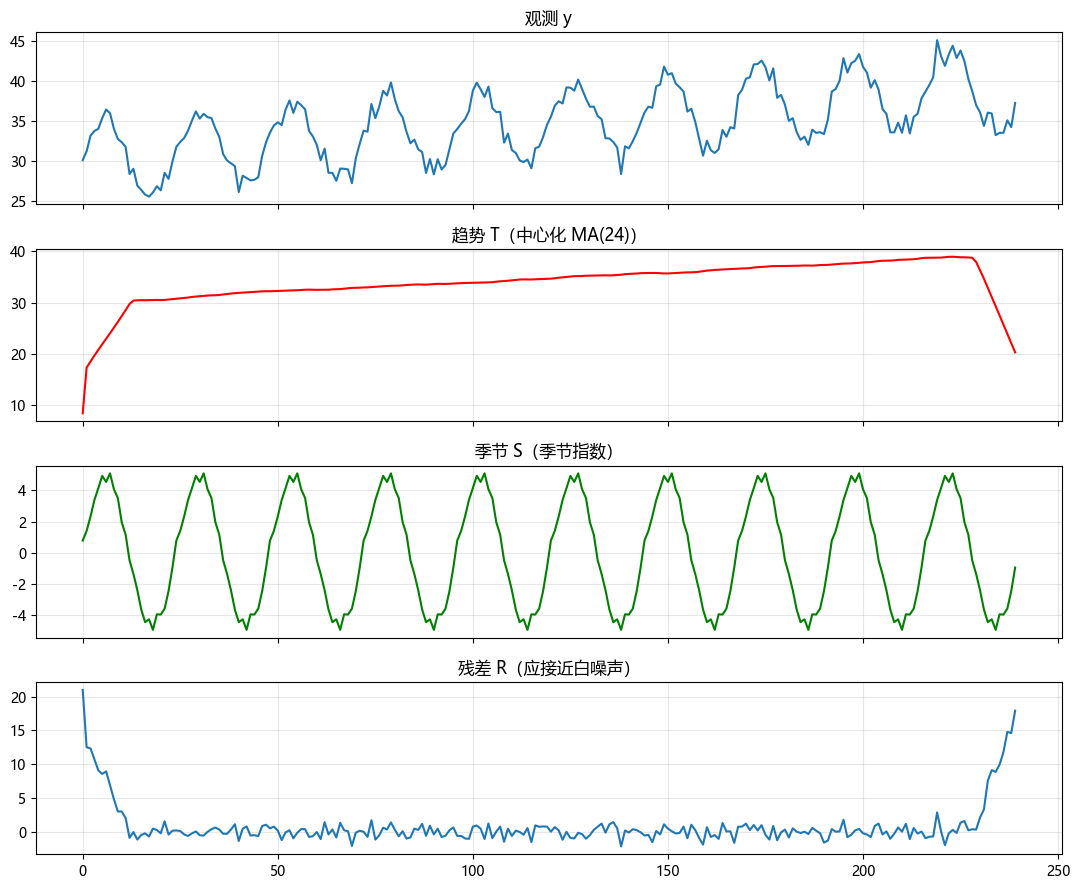

残差标准差(裁剪边界)=0.805（噪声真值 0.9）| 季节幅度估计=10.016（真值 10）
要点：残差≈白噪声 + 季节幅度≈2×振幅，说明分解把结构"提"干净了


In [1]:
# ---------- 实验 1：手写经典分解（中心化移动平均 + 季节指数） ----------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(0)

n = 240; m = 24                                    # 24 个季节周期
t = np.arange(n)
y = 30 + 0.04 * t + 5 * np.sin(2 * np.pi * t / m) + rng.normal(0, 0.9, n)

def centered_ma(x, m):
    # 偶数周期用两步平均（中心化）：先 m 期平均再 2 期平均
    pad = m // 2
    c = np.convolve(x, np.ones(m) / m, mode='same')
    c = np.convolve(c, np.ones(2) / 2, mode='same') if m % 2 == 0 else c
    return c

trend = centered_ma(y, m)
detrend = y - trend
# 季节指数只用 MA 边界效应区之外的样本（'same' 卷积首尾约 m/2 个点不可靠）
season = np.zeros(m); cnt = np.zeros(m)
for i in range(m // 2, n - m // 2):
    season[i % m] += detrend[i]; cnt[i % m] += 1
season /= cnt
season_full = np.tile(season, n // m + 1)[:n]
resid = y - trend - season_full

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(y); axes[0].set_title('观测 y')
axes[1].plot(trend, 'r'); axes[1].set_title('趋势 T（中心化 MA(24)）')
axes[2].plot(season_full, 'g'); axes[2].set_title('季节 S（季节指数）')
axes[3].plot(resid); axes[3].set_title('残差 R（应接近白噪声）')
for a in axes: a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts03_decomp.png', dpi=110, bbox_inches='tight'); plt.show()

print('残差标准差(裁剪边界)=%.3f（噪声真值 0.9）| 季节幅度估计=%.3f（真值 10）' %
      (resid[12:-12].std(), season.max() - season.min()))
assert resid[12:-12].std() < 1.5 and abs((season.max() - season.min()) - 10) < 2
print('要点：残差≈白噪声 + 季节幅度≈2×振幅，说明分解把结构"提"干净了')


## 2. 季节指数与分解质量

- 季节指数 = 各周期位置的去趋势均值——若该位置显著偏离 0，说明确有季节
- **残差占比** $= \\text{Var}(R)/\\text{Var}(y)$：占比越小分解解释力越强
- 判断残差是否"干净"：Ljung-Box 检验（00 篇）——通过 = 无残留结构


In [2]:
# ---------- 实验 2：残差诊断 + 分解质量量化 ----------
from math import erf, sqrt

def chi2_cdf_approx(x, df):
    z = ((x / df) ** (1 / 3) - (1 - 2 / (9 * df))) / sqrt(2 / (9 * df))
    return 0.5 * (1 + erf(z / sqrt(2)))

def acf(x, max_lag=20):
    x = x - x.mean()
    v = np.dot(x, x)
    out = [1.0]                                        # ρ(0) ≡ 1，注意 x[:-0] 是空数组
    for k in range(1, max_lag + 1):
        out.append(np.dot(x[k:], x[:-k]) / v)
    return np.array(out)

def ljung_box(x, h=10):
    a = acf(x, h)[1:]
    Q = len(x) * (len(x) + 2) * np.sum(a ** 2 / (len(x) - np.arange(1, h + 1)))
    return Q, 1 - chi2_cdf_approx(Q, h)

rc = resid[12:-12]                            # 裁剪 MA 边界效应区
Q, pv = ljung_box(rc)
share = rc.var() / y[12:-12].var()
print('残差 Ljung-Box: Q=%.2f p=%.3f（p>0.05 → 无残留自相关）' % (Q, pv))
print('残差方差占比: %.1f%%（越小说明趋势+季节解释力越强）' % (100 * share))
assert pv > 0.05 and share < 0.1
print('结论：分解成功——残差白噪声、方差占比低，可直接对残差建模型或放心用季节外推')


残差 Ljung-Box: Q=8.84 p=0.549（p>0.05 → 无残留自相关）
残差方差占比: 3.3%（越小说明趋势+季节解释力越强）
结论：分解成功——残差白噪声、方差占比低，可直接对残差建模型或放心用季节外推


## 3. STL：现代分解方法

**STL（Seasonal-Trend decomposition using LOESS）**：用 LOESS 局部回归迭代估计趋势与季节，交替平滑、内循环外循环，天然处理：
- 季节形状可随时间**缓慢变化**（经典分解假设固定形状）
- 对异常点鲁棒（外循环降权）
- 可加性框架，任意周期

> 对比一句话：**经典分解 = 移动平均 + 均值；STL = 局部回归迭代 + 鲁棒加权**。


## 4. 面试速答（30 秒背诵版）

- **加法 vs 乘法**：季节幅度是否随水平变化；对数把乘法变加法
- **经典三步**：MA 去趋势 → 周期均值季节指数 → 残差
- **中心化 MA**：偶数周期需两步平均对齐时间点
- **STL**：LOESS 迭代、季节可漂移、鲁棒
- **残差诊断**：Ljung-Box + 方差占比；残差不白噪声 → 结构没提干净
- **用途**：EDA 报告、季节性调整（经济数据）、残差建模、异常检测基线

**易错点**：季节周期 m 必须是已知/先验；首尾 MA 边界值不可靠；乘法模型要求 y>0


## 5. 自测清单

- [ ] 手写中心化移动平均（偶数周期两步平均）
- [ ] 手写季节指数（去趋势后周期位置均值）
- [ ] 手写残差诊断（Ljung-Box）并解释 p 值
- [ ] 计算残差方差占比并解释含义
- [ ] 说清 STL 与经典分解的三个差异
- [ ] 手绘加法/乘法分解示意图
- [ ] 说出分解的三个应用场景

> 💡 下一篇 `04-特征工程与机器学习` 把"手工结构"换成"自动特征 + 模型"。
